# Exponential Search for Representative Pareto

In [1]:
from paretoKnapsackTeams import *
import shutil
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Enable LaTeX rendering if available
if shutil.which("latex"):
    mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
    })
else:
    mpl.rcParams.update({"text.usetex": False})

# Set style
# plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = (12, 8)
mpl.rcParams['font.size'] = 10

In [2]:
# Load datasets
print("Loading datasets...")

# IMDB
imdb_experts_1, imdb_tasks_1, imdb_costs_1, imdb_graphmat_1 = import_pickled_datasets('imdb', 1)

# Bibsonomy
bbsm_experts_1, bbsm_tasks_1, bbsm_costs_1, bbsm_graphmat_1 = import_pickled_datasets('bbsm', 1)

# Freelancer
fl_experts_1, fl_tasks_1, fl_costs_1, fl_graphmat_1 = import_pickled_datasets('freelancer', 1)

print(f"IMDB: {len(imdb_experts_1)} experts, {len(imdb_tasks_1)} tasks")
print(f"Bibsonomy: {len(bbsm_experts_1)} experts, {len(bbsm_tasks_1)} tasks")
print(f"Freelancer: {len(fl_experts_1)} experts, {len(fl_tasks_1)} tasks")

# Select dataset to test with
dataset_name = 'imdb'
experts = imdb_experts_1
tasks = imdb_tasks_1
costs = imdb_costs_1

# Parameters
num_experts = min(50, len(experts))
num_tasks = min(5, len(tasks))
max_budget = 500

print(f"\nUsing {dataset_name} dataset with {num_experts} experts, {num_tasks} tasks, budget {max_budget}")

2026-05-13 13:43:03,946 |INFO: Imported imdb experts, Num Experts: 200
2026-05-13 13:43:03,947 |INFO: Imported imdb tasks, Num Tasks: 300
2026-05-13 13:43:03,948 |INFO: Imported imdb costs, Num Costs: 200
2026-05-13 13:43:03,952 |INFO: Imported imdb graph matrix, Shape: (1000, 1000)

2026-05-13 13:43:03,953 |INFO: Imported bbsm experts, Num Experts: 250
2026-05-13 13:43:03,954 |INFO: Imported bbsm tasks, Num Tasks: 300
2026-05-13 13:43:03,955 |INFO: Imported bbsm costs, Num Costs: 250
2026-05-13 13:43:03,957 |INFO: Imported bbsm graph matrix, Shape: (500, 500)

2026-05-13 13:43:03,958 |INFO: Imported freelancer experts, Num Experts: 50
2026-05-13 13:43:03,959 |INFO: Imported freelancer tasks, Num Tasks: 250
2026-05-13 13:43:03,960 |INFO: Imported freelancer costs, Num Costs: 50
2026-05-13 13:43:03,961 |INFO: Imported freelancer graph matrix, Shape: (50, 50)



Loading datasets...
IMDB: 200 experts, 300 tasks
Bibsonomy: 250 experts, 300 tasks
Freelancer: 50 experts, 250 tasks

Using imdb dataset with 50 experts, 5 tasks, budget 500


## 3. Run Exponential Search

In [3]:
print("Testing Exponential Search for Representative Pareto Intervals...\n")

# Parameters
epsilon = 0.2
delta = 0.05
min_budget = 10
max_budget = 600
num_tasks_to_test = 5
size_univ_dict ={'imdb':24, 'bbsm':75, 'freelancer':50}

# Prepare datasets
datasets = {
    'imdb': (imdb_experts_1, imdb_tasks_1, imdb_costs_1),
    'bbsm': (bbsm_experts_1, bbsm_tasks_1, bbsm_costs_1),
    'freelancer': (fl_experts_1, fl_tasks_1, fl_costs_1)
}

# Store results: results[dataset_name][task_idx] = (P_R, metadata, coverages, budgets)
results = {}

for dataset_name, (experts, tasks, costs) in datasets.items():
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    
    results[dataset_name] = {}
    num_experts = min(50, len(experts))
    
    for task_idx in range(min(num_tasks_to_test, len(tasks))):
        current_task = tasks[task_idx]
        
        print(f"\nTask {task_idx + 1}/{min(num_tasks_to_test, len(tasks))}: Testing exponential search")
        print(f"  Budget range: [{min_budget}, {max_budget}]")
        
        # Initialize Pareto instance
        pareto_instance = paretoKnapsackTeams(
            task=current_task,
            n_experts=experts[:num_experts],
            costs=costs[:num_experts],
            size_univ=size_univ_dict[dataset_name],
            budget=max_budget
        )
        
        # Run exponential search
        P_R, metadata = pareto_instance.exponentialSearchRepresentativeIntervals(
            B_min=min_budget,
            B_max=max_budget,
            epsilon_val=epsilon,
            delta_val=delta
        )
        
        # Extract coverages and budgets
        coverages = []
        budgets = []
        for experts_list, interval in P_R:
            skills = set()
            for expert in experts_list:
                skills = skills.union(set(expert))
            coverage = len(skills.intersection(set(current_task))) / len(current_task) if len(current_task) > 0 else 0
            coverages.append(coverage)
            budgets.append(interval[0])  # Use left endpoint
        
        # Store results
        results[dataset_name][task_idx] = {
            'P_R': P_R,
            'metadata': metadata,
            'coverages': np.array(coverages),
            'budgets': np.array(budgets),
            'num_intervals': len(P_R)
        }
        
        print(f"  ✓ Found {len(P_R)} intervals, avg coverage: {np.mean(coverages):.4f}")

print(f"\n{'='*70}")
print("Exponential Search Complete for all datasets and tasks!")
print(f"{'='*70}")


2026-05-13 13:43:03,975 |INFO: Exponential Search Iteration 1: l=10


Testing Exponential Search for Representative Pareto Intervals...


Dataset: imdb

Task 1/5: Testing exponential search
  Budget range: [10, 600]


2026-05-13 13:43:05,514 |INFO: Added interval: [l=10.00, r'=30.00], v_l=0.375, experts=1
2026-05-13 13:43:05,515 |INFO: Exponential Search Iteration 2: l=29.9999994336914
2026-05-13 13:43:06,868 |INFO: Added interval: [l=30.00, r'=40.00], v_l=0.625, experts=2
2026-05-13 13:43:06,869 |INFO: Exponential Search Iteration 3: l=39.999999936335726
2026-05-13 13:43:08,370 |INFO: Added interval: [l=40.00, r'=80.00], v_l=0.750, experts=3
2026-05-13 13:43:08,371 |INFO: Exponential Search Iteration 4: l=79.99999991081845
2026-05-13 13:43:10,007 |INFO: Added interval: [l=80.00, r'=310.00], v_l=0.875, experts=5
2026-05-13 13:43:10,007 |INFO: Exponential Search Iteration 5: l=309.99999966399173
2026-05-13 13:43:10,079 |INFO: Added interval: [l=310.00, r'=446.40], v_l=1.000, experts=5
2026-05-13 13:43:10,080 |INFO: Full coverage (v_l=1.0000) achieved at l=310.00, stopping search
2026-05-13 13:43:10,081 |INFO: Exponential Search Complete: 5 intervals found, Runtime=6.11s
2026-05-13 13:43:10,082 |INFO:

  ✓ Found 5 intervals, avg coverage: 0.7250

Task 2/5: Testing exponential search
  Budget range: [10, 600]


2026-05-13 13:43:10,948 |INFO: Added interval: [l=10.00, r'=50.00], v_l=0.400, experts=1
2026-05-13 13:43:10,949 |INFO: Exponential Search Iteration 2: l=49.99999985824216
2026-05-13 13:43:11,815 |INFO: Added interval: [l=50.00, r'=150.00], v_l=0.800, experts=3
2026-05-13 13:43:11,815 |INFO: Exponential Search Iteration 3: l=149.99999967982902
2026-05-13 13:43:11,908 |INFO: Added interval: [l=150.00, r'=447.90], v_l=1.000, experts=4
2026-05-13 13:43:11,909 |INFO: Full coverage (v_l=1.0000) achieved at l=150.00, stopping search
2026-05-13 13:43:11,910 |INFO: Exponential Search Complete: 3 intervals found, Runtime=1.83s
2026-05-13 13:43:11,910 |INFO: Exponential Search Iteration 1: l=10


...

  ✓ Found 3 intervals, avg coverage: 0.3333

Task 4/5: Testing exponential search
  Budget range: [10, 600]


2026-05-13 13:43:44,767 |INFO: Added interval: [l=10.00, r'=30.00], v_l=0.200, experts=1
2026-05-13 13:43:44,768 |INFO: Exponential Search Iteration 2: l=29.9999994336914
2026-05-13 13:43:46,430 |INFO: Added interval: [l=30.00, r'=190.00], v_l=0.400, experts=2
2026-05-13 13:43:46,431 |INFO: Exponential Search Iteration 3: l=190.00000046329848
2026-05-13 13:43:46,595 |INFO: Added interval: [l=190.00, r'=567.34], v_l=0.800, experts=7
2026-05-13 13:43:46,596 |INFO: Exponential Search Iteration 4: l=567.3369613834018
2026-05-13 13:43:46,662 |INFO: Added interval: [l=567.34, r'=600.00], v_l=0.800, experts=13
2026-05-13 13:43:46,663 |INFO: Exponential Search Complete: 4 intervals found, Runtime=3.31s
2026-05-13 13:43:46,663 |INFO: Exponential Search Iteration 1: l=10


  ✓ Found 4 intervals, avg coverage: 0.5500

Task 5/5: Testing exponential search
  Budget range: [10, 600]


2026-05-13 13:43:47,468 |INFO: Added interval: [l=10.00, r'=50.00], v_l=0.250, experts=1
2026-05-13 13:43:47,469 |INFO: Exponential Search Iteration 2: l=49.99999985824216
2026-05-13 13:43:48,238 |INFO: Added interval: [l=50.00, r'=160.00], v_l=0.750, experts=4
2026-05-13 13:43:48,239 |INFO: Exponential Search Iteration 3: l=160.000000020374
2026-05-13 13:43:48,334 |INFO: Added interval: [l=160.00, r'=477.76], v_l=1.000, experts=3
2026-05-13 13:43:48,335 |INFO: Full coverage (v_l=1.0000) achieved at l=160.00, stopping search
2026-05-13 13:43:48,336 |INFO: Exponential Search Complete: 3 intervals found, Runtime=1.67s


  ✓ Found 3 intervals, avg coverage: 0.6667

Exponential Search Complete for all datasets and tasks!


In [4]:
results['imdb'][0]

{'P_R': [([[2, 3, 4]], (10, 29.9999994336914)),
  ([[2, 3, 4], [1, 5]], (29.9999994336914, 39.999999936335726)),
  ([[2, 3, 4], [1, 5], [4, 7]], (39.999999936335726, 79.99999991081845)),
  ([[2, 3, 4], [1, 5], [4, 7], [1, 6, 7, 16], [1, 14]],
   (79.99999991081845, 309.99999966399173)),
  ([[7, 15, 16], [2, 3, 4], [1, 5], [1, 6, 7, 16], [0, 23]],
   (309.99999966399173, 446.39999951614806))],
 'metadata': {'epsilon': 0.2,
  'delta': 0.05,
  'B_min': 10,
  'B_max': 600,
  'num_intervals': 5,
  'runtime': 6.105868999962695},
 'coverages': array([0.375, 0.625, 0.75 , 0.875, 1.   ]),
 'budgets': array([ 10.        ,  29.99999943,  39.99999994,  79.99999991,
        309.99999966]),
 'num_intervals': 5}

## Plot

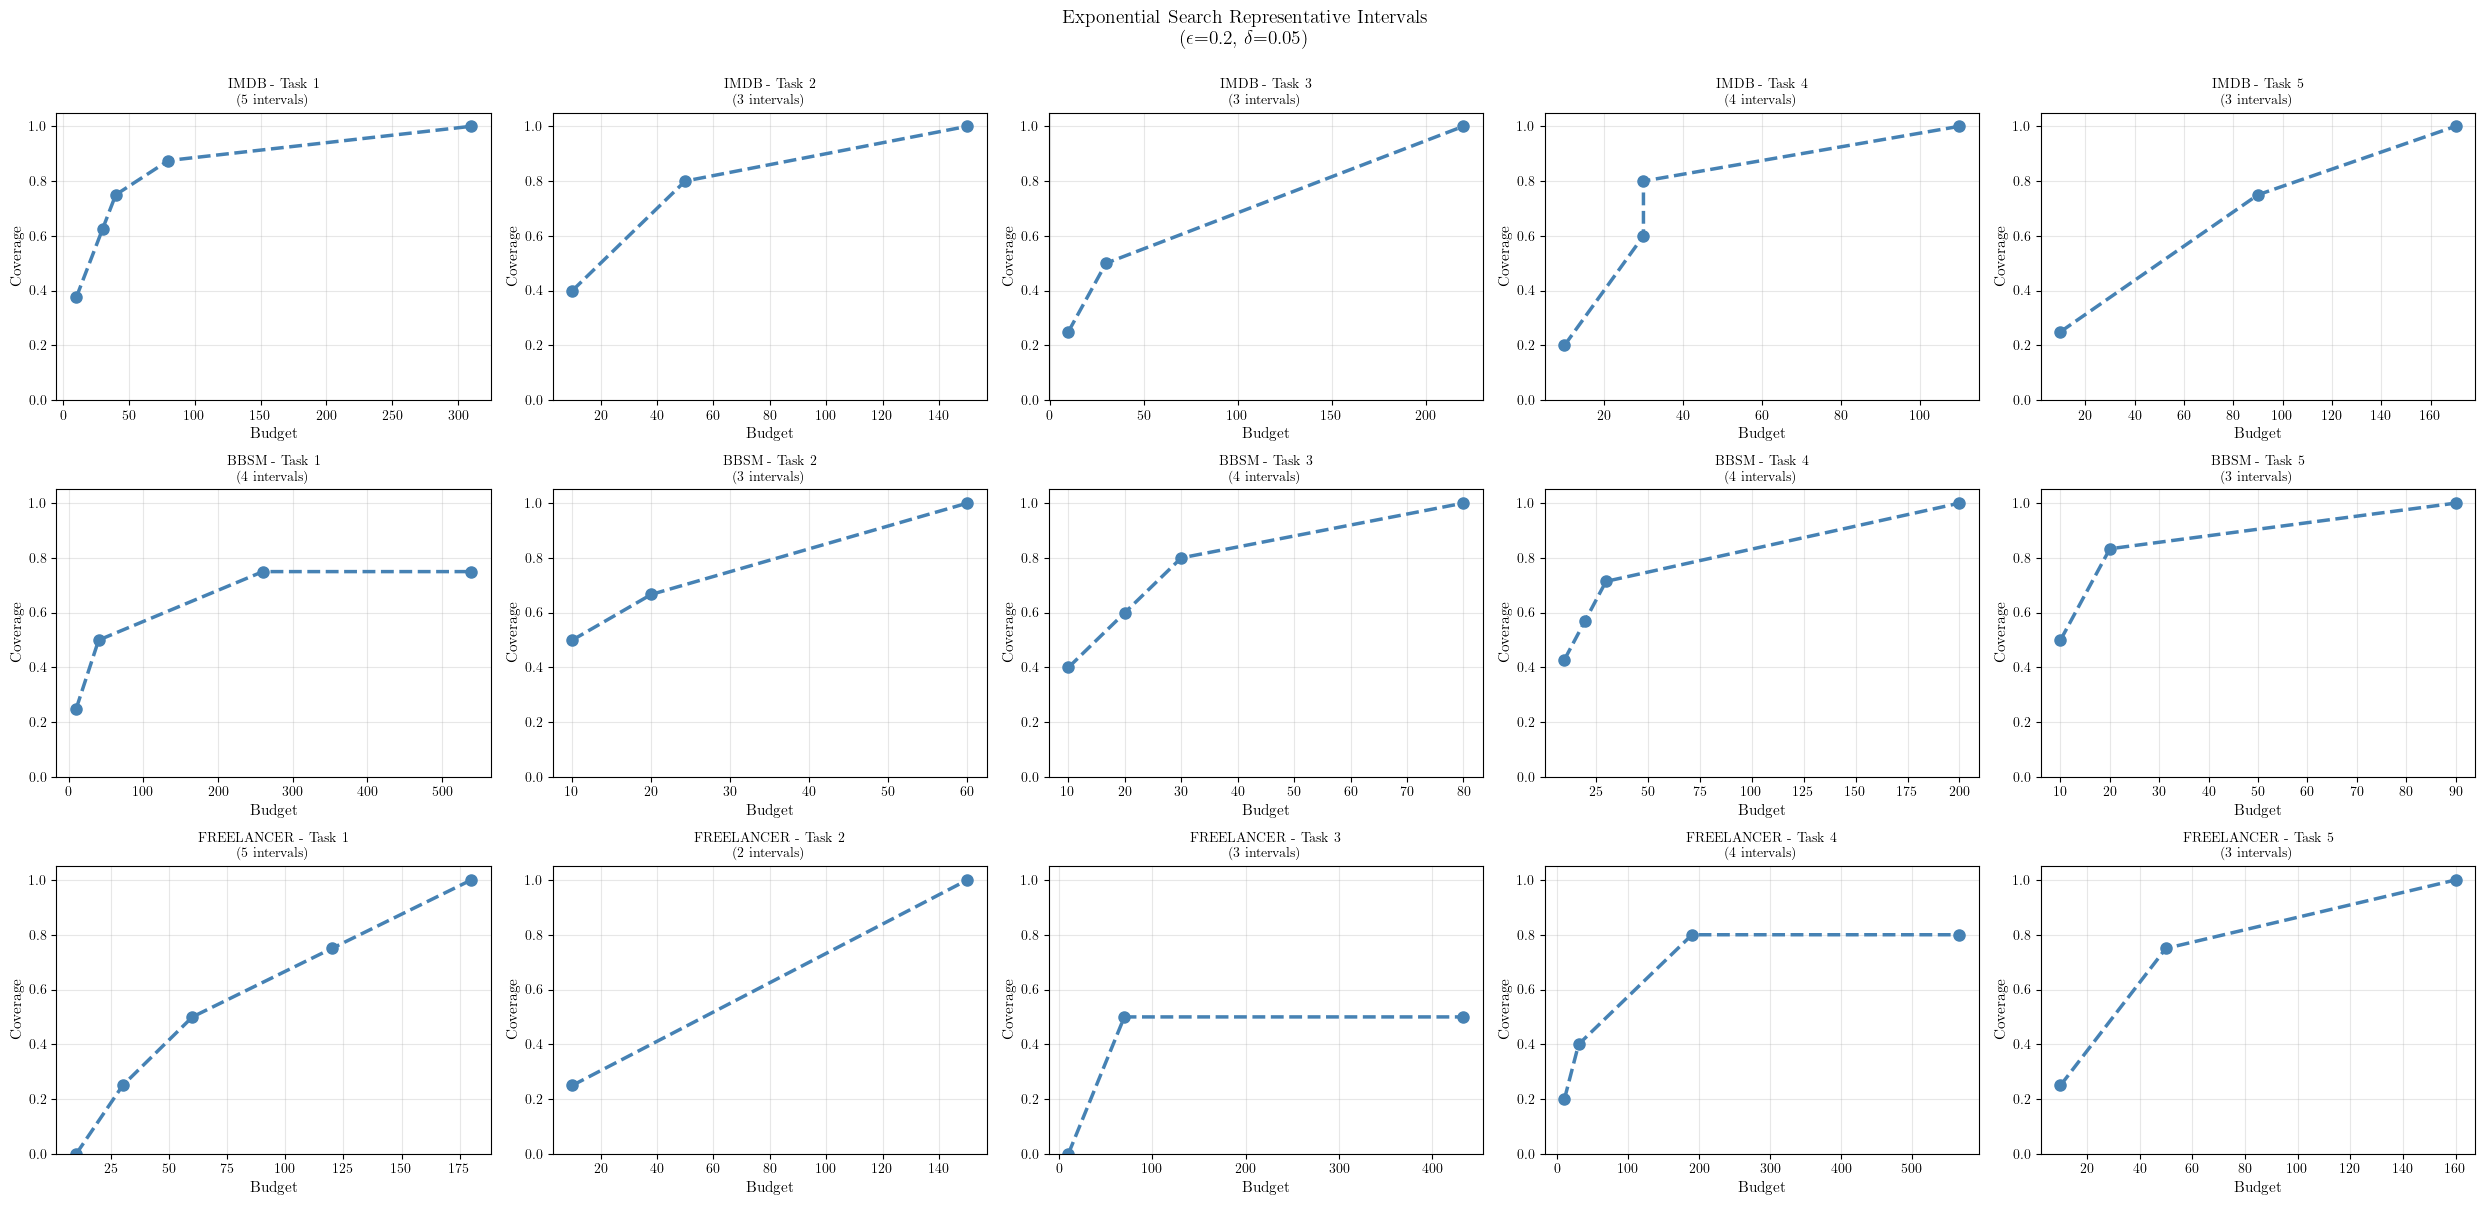

In [6]:
# Create grid of plots for all datasets and tasks
num_datasets = len(datasets)
num_tasks_displayed = max(len(results[d]) for d in results.keys())

fig, axes = plt.subplots(num_datasets, num_tasks_displayed, figsize=(5*num_tasks_displayed, 4*num_datasets))

# Ensure axes is 2D
if num_datasets == 1:
    axes = axes.reshape(1, -1)
if num_tasks_displayed == 1:
    axes = axes.reshape(-1, 1)

# Plot each result
for row, (dataset_name, dataset_results) in enumerate(results.items()):
    for col in range(num_tasks_displayed):
        ax = axes[row, col]
        
        if col in dataset_results:
            result = dataset_results[col]
            coverages = result['coverages']
            budgets = result['budgets']
            
            ax.plot(budgets, coverages, 
                   color='steelblue', linestyle='--', linewidth=2.5, 
                   marker='o', markersize=8, label='Rep. Intervals')
            
            ax.set_xlabel('Budget', fontsize=11, fontweight='bold')
            ax.set_ylabel('Coverage', fontsize=11, fontweight='bold')
            ax.set_title(f'{dataset_name.upper()} - Task {col+1}\n({result["num_intervals"]} intervals)',
                        fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle(f'Exponential Search Representative Intervals\n($\\epsilon$={epsilon}, $\\delta$={delta})', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
